# 16-2. PCA와 SHAP 입문

16장에서 permutation importance로 모델 해석을 배웠다.

이번 노트북에서는 두 가지 도구를 추가로 만난다.

```text
PCA: 데이터 구조를 보기 위한 차원 축소
SHAP: 모델 예측을 설명하기 위한 도구
```

둘의 목적이 다르다는 점을 계속 기억하자.


In [1]:

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score

np.random.seed(42)


## 데이터 불러오기

가능하면 `diabetes_or_cardiovascular` 폴더의 건강 지표 데이터를 사용한다.
없으면 기본 `diabetes.csv`를 사용한다.


In [2]:

data_path = Path(r"C:\work\dataset\diabetes_or_cardiovascular\diabetes_binary_health_indicators_BRFSS2015.csv")
if not data_path.exists():
    data_path = Path(r"C:\work\dataset\diabetes.csv")

df = pd.read_csv(data_path)

print("사용 데이터:", data_path)
print("데이터 모양:", df.shape)
df.head()


사용 데이터: C:\work\dataset\diabetes_or_cardiovascular\diabetes_binary_health_indicators_BRFSS2015.csv
데이터 모양: (253680, 22)


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [3]:

# 데이터마다 타깃 컬럼 이름이 다를 수 있으므로 후보를 순서대로 확인한다.
target_candidates = ["Diabetes_binary", "Outcome", "target"]
target_col = next((col for col in target_candidates if col in df.columns), df.columns[-1])

X = df.drop(columns=[target_col])
y = df[target_col]

# 너무 큰 데이터는 입문 실습에서 오래 걸릴 수 있으므로 일부만 사용한다.
sample_size = min(len(df), 5000)
X = X.iloc[:sample_size].copy()
y = y.iloc[:sample_size].copy()

print("target column:", target_col)
print("X shape:", X.shape)
print("y value counts:")
print(y.value_counts())


target column: Diabetes_binary
X shape: (5000, 21)
y value counts:
Diabetes_binary
0.0    4086
1.0     914
Name: count, dtype: int64


## PCA로 데이터 구조 보기

PCA는 모델 예측 이유를 설명하는 도구가 아니다.
여러 특성을 2개 축으로 압축해서 데이터가 대략 어떻게 퍼져 있는지 보는 도구다.

PCA는 거리와 분산의 영향을 받으므로 먼저 표준화한다.


In [4]:

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "target": y.values,
})

pca_df.head()


,PC1,PC2,target
0,4.016845,0.287897,0.0
1,0.449936,-5.588381,0.0
2,4.315091,-0.917214,0.0
3,-0.731421,0.742437,0.0
4,-0.523960,1.293972,0.0


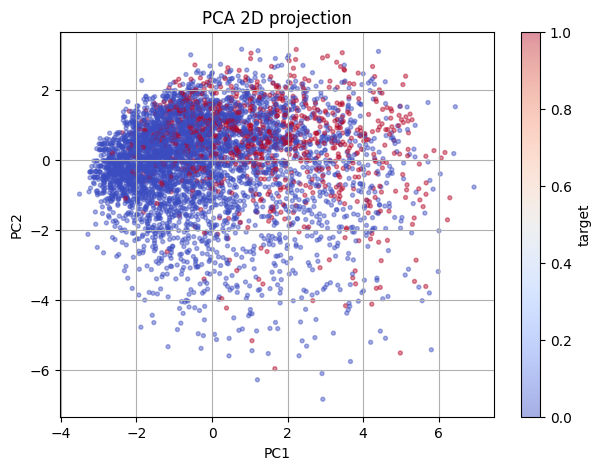

PC1, PC2 explained variance ratio: [0.1764065 0.0876281]
PC1+PC2 total: 0.26403459858275713


In [5]:

plt.figure(figsize=(7, 5))
scatter = plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=pca_df["target"],
    s=8,
    cmap="coolwarm",
    alpha=0.45,
)
plt.title("PCA 2D projection")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(scatter, label="target")
plt.grid(True)
plt.show()

print("PC1, PC2 explained variance ratio:", pca.explained_variance_ratio_)
print("PC1+PC2 total:", pca.explained_variance_ratio_.sum())


## 모델을 하나 만들고 중요도 보기

SHAP와 permutation importance를 이해하려면 먼저 예측 모델이 필요하다.

여기서는 빠르게 학습되는 `RandomForestClassifier`를 사용한다.
딥러닝 모델은 아니지만, 해석 도구의 의미를 연습하기에는 충분하다.


In [6]:

stratify_y = y if y.nunique() == 2 and y.value_counts().min() >= 2 else None

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=stratify_y,
)

model = RandomForestClassifier(
    n_estimators=80,
    random_state=42,
    n_jobs=1,
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("accuracy:", accuracy_score(y_test, y_pred))
print("f1:", f1_score(y_test, y_pred, average="binary" if y.nunique() == 2 else "weighted"))


accuracy: 0.823
f1: 0.21333333333333335


## Permutation Importance 복습

Permutation importance는 16장에서 배운 방식이다.

특정 특성 하나를 섞었을 때 모델 성능이 얼마나 떨어지는지 본다.


In [7]:

importance = permutation_importance(
    model,
    X_test,
    y_test,
    n_repeats=3,
    random_state=42,
    n_jobs=1,
)

importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance_mean": importance.importances_mean,
    "importance_std": importance.importances_std,
}).sort_values("importance_mean", ascending=False)

importance_df.head(10)


,feature,importance_mean,importance_std
3,BMI,0.013333,0.001700
16,DiffWalk,0.006667,0.000943
13,GenHlth,0.005333,0.002494
14,MentHlth,0.005333,0.000943
18,Age,0.005333,0.006342
20,Income,0.004667,0.001700
5,Stroke,0.004000,0.000816
6,HeartDiseaseorAttack,0.003333,0.000943
1,HighChol,0.002667,0.001247
0,HighBP,0.001667,0.004989


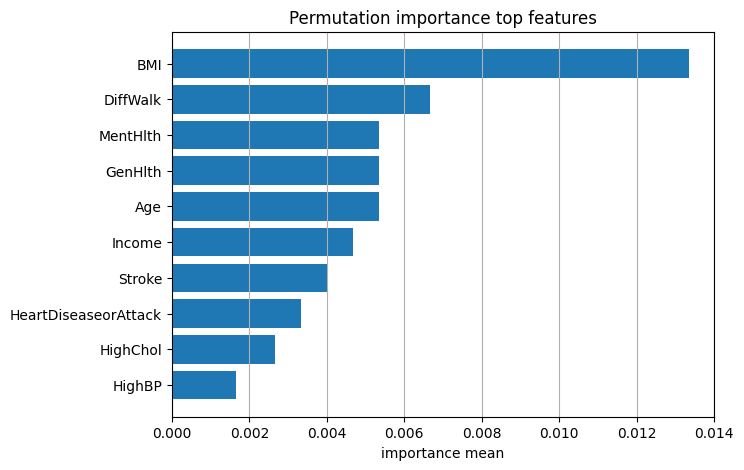

In [8]:

top_n = min(10, len(importance_df))
top_importance = importance_df.head(top_n).sort_values("importance_mean")

plt.figure(figsize=(7, 5))
plt.barh(top_importance["feature"], top_importance["importance_mean"])
plt.title("Permutation importance top features")
plt.xlabel("importance mean")
plt.grid(True, axis="x")
plt.show()


## SHAP 선택 실습

SHAP는 설치되어 있지 않을 수 있다.
설치되어 있으면 작은 샘플에 대해 SHAP 값을 계산해본다.

설치되어 있지 않아도 이 노트북은 실패하지 않는다.


In [9]:

try:
    import shap

    # TreeExplainer는 RandomForest 같은 tree 모델에 자주 사용된다.
    explainer = shap.TreeExplainer(model)
    shap_sample = X_test.iloc[:100]
    shap_values = explainer.shap_values(shap_sample)

    print("SHAP 계산 완료")
    print("샘플 수:", len(shap_sample))

    # shap_values의 구조는 SHAP 버전과 모델 유형에 따라 다를 수 있다.
    if isinstance(shap_values, list):
        print("SHAP output: list, length =", len(shap_values))
        selected_values = shap_values[-1]
    else:
        print("SHAP output shape:", np.array(shap_values).shape)
        selected_values = shap_values

    print("선택한 SHAP 값 배열 shape:", np.array(selected_values).shape)
except ImportError:
    shap = None
    selected_values = None
    shap_sample = None
    print("shap가 설치되어 있지 않습니다. 필요하면 pip install shap 로 설치하세요.")


shap가 설치되어 있지 않습니다. 필요하면 pip install shap 로 설치하세요.


In [10]:

# SHAP가 계산된 경우, 특성별 평균 절대 SHAP 값을 표로 정리한다.
# 이는 각 특성이 예측에 얼마나 크게 영향을 주는지 대략 보는 방식이다.
if selected_values is not None:
    values = np.array(selected_values)

    # 이진분류에서 shape가 (samples, features, classes)처럼 나오는 경우가 있어 처리한다.
    if values.ndim == 3:
        values = values[:, :, -1]

    shap_importance_df = pd.DataFrame({
        "feature": shap_sample.columns,
        "mean_abs_shap": np.abs(values).mean(axis=0),
    }).sort_values("mean_abs_shap", ascending=False)

    display(shap_importance_df.head(10))
else:
    print("SHAP 결과가 없어 이 셀은 표를 만들지 않습니다.")


SHAP 결과가 없어 이 셀은 표를 만들지 않습니다.


## 정리

이번 노트북에서 도구를 세 가지로 나누어 보았다.

```text
PCA:
데이터를 2차원으로 줄여 구조를 본다.

Permutation importance:
특성을 섞었을 때 전체 성능이 얼마나 떨어지는지 본다.

SHAP:
각 특성이 예측값을 어느 방향으로 얼마나 밀었는지 설명하려는 도구다.
```

세 도구 모두 인과관계를 증명하지 않는다.
모델과 데이터를 더 잘 이해하기 위한 도구로 사용해야 한다.
